In [45]:
import sys
#sys.path.insert(1, '/home/santolam/MyPythonLibrary/MAR-RECAP/libmar/')
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
#sys.path.insert(1, '/Users/santolam/Documents/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from scipy.stats import pearsonr
import pandas as pd

In [3]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [4]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [5]:
domain_2 = 'GRp'

In [7]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='//bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/daily/'

sourceData_3='//bettik/PROJECTS/pr-regional-climate/santolam/AWS_Pamir/CR800/' 

folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [8]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [9]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le forage 2025")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le forage 2025
Indice Y : 26
Indice X : 47
Latitude : 38.54820251464844
Longitude : 72.30000305175781
Altitude : 5300.28369140625


/tmp/ipykernel_936106/4011659233.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


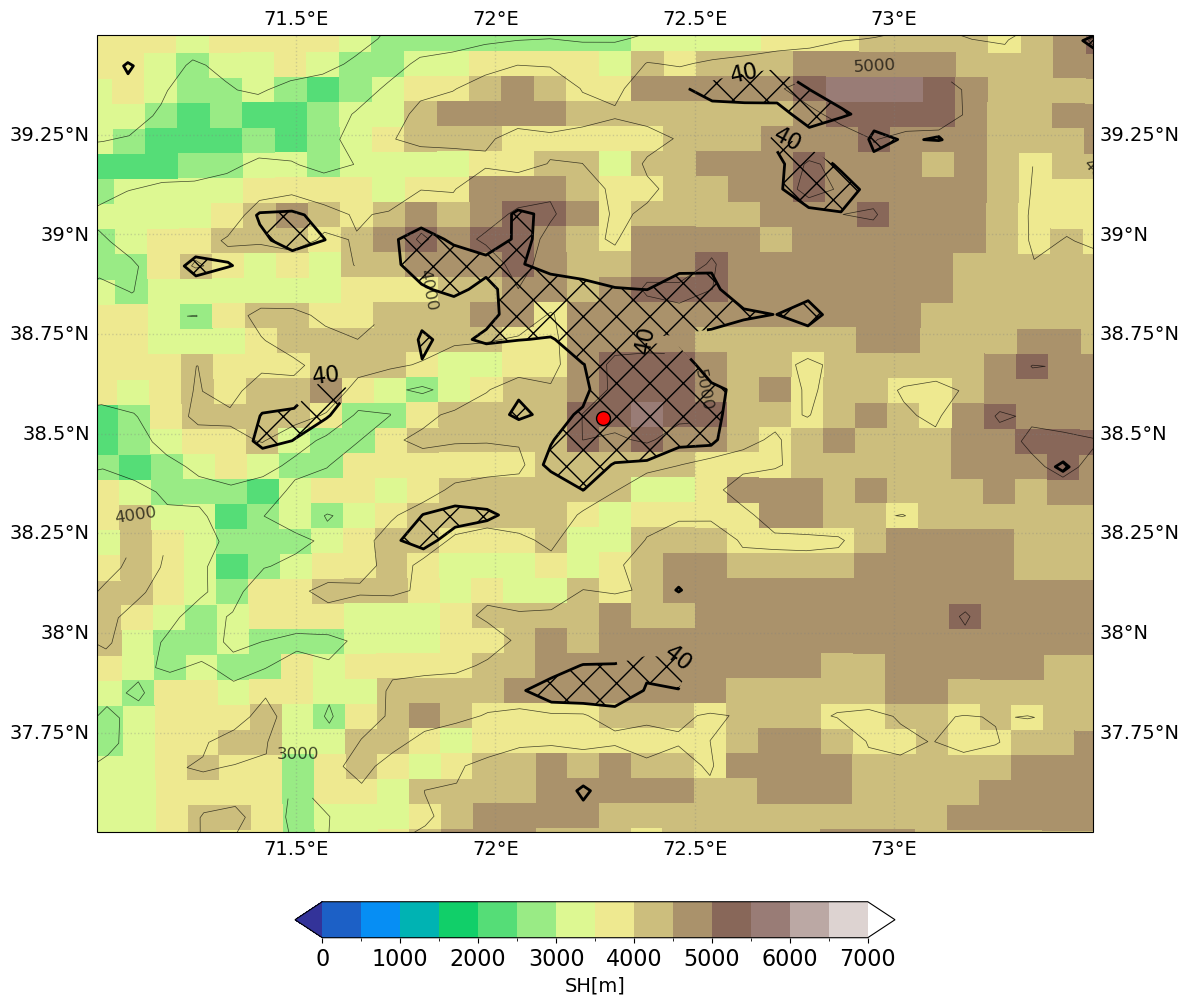

In [10]:
ice_level=40# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
ax.set_extent([71, 73.5, 37.5, 39.5], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Jasgulem ice core : red dot
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

plt.show()

### MAR dataset

In [11]:
variable='TTZ'

ds_TTZ = xr.open_mfdataset(sourceData_1 + "TTZ_monmean_MARv3.14_ER5_spin2_GRp_*.nc").isel(ZTQLEV=0).TTZ.load()

ds_TTZ = ds_TTZ.assign_coords(X=np.round(ds_TTZ.X.values))
ds_TTZ = ds_TTZ.assign_coords(Y=np.round(ds_TTZ.Y.values))
ds_TTZ = ds_TTZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZ = ds_TTZ[:,k:-k,k:-k]

In [12]:
variable='SF'

ds_SF = xr.open_mfdataset(sourceData_1 + "SF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

### AWS CR800 dataset

In [36]:
data = np.genfromtxt(
    sourceData_3 + 'CR800Series_MetData_60min.dat',
    delimiter=",",
    skip_header=4,
    dtype=None,
    encoding="utf-8",
    missing_values="NAN",
    filling_values=np.nan
)

time_str = np.char.strip(data['f0'], '"')

time_cr800_hr = time_str.astype('datetime64[s]')
T_cr800_hr = data['f7']

In [37]:
data = np.genfromtxt(
    sourceData_3 + 'CR800Series_MetData_24hour.dat',
    delimiter=",",
    skip_header=4,
    dtype=None,
    encoding="utf-8",
    missing_values="NAN",
    filling_values=np.nan
)

time_str = np.char.strip(data['f0'], '"')

time_cr800_dy = time_str.astype('datetime64[s]')
T_cr800_dy = data['f7']

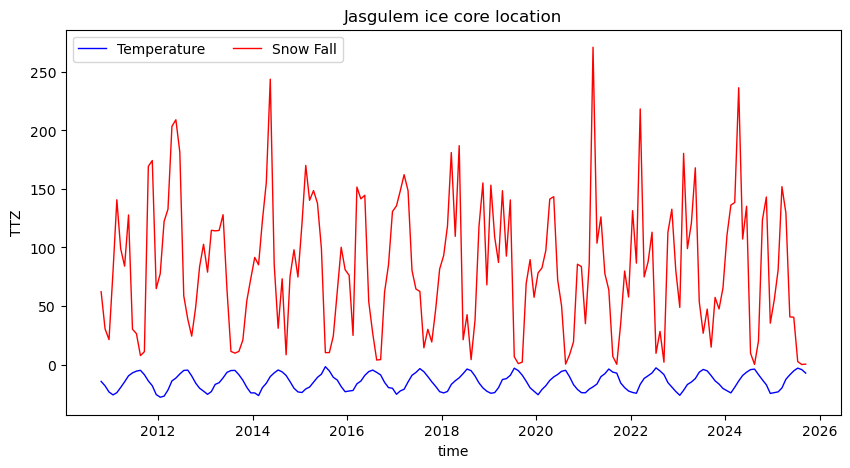

In [13]:
# monthly TTZ and SF at Jasgulem ice core site

plt.figure(figsize=(10,5))

ds_TTZ_jasg =  ds_TTZ.isel(Y=iY, X=iX).sel(time=slice("2010-09-30", "2025-10-01"))
ds_TTZ_jasg.plot(label="Temperature", linewidth=1, color="blue")

ds_SF_jasg =  ds_SF.isel(Y=iY, X=iX).sel(time=slice("2010-09-30", "2025-10-01"))
ds_SF_jasg.plot(label="Snow Fall", linewidth=1, color="red")


plt.legend(ncol=3)
plt.title("Jasgulem ice core location")
plt.ylabel("TTZ")
plt.show()

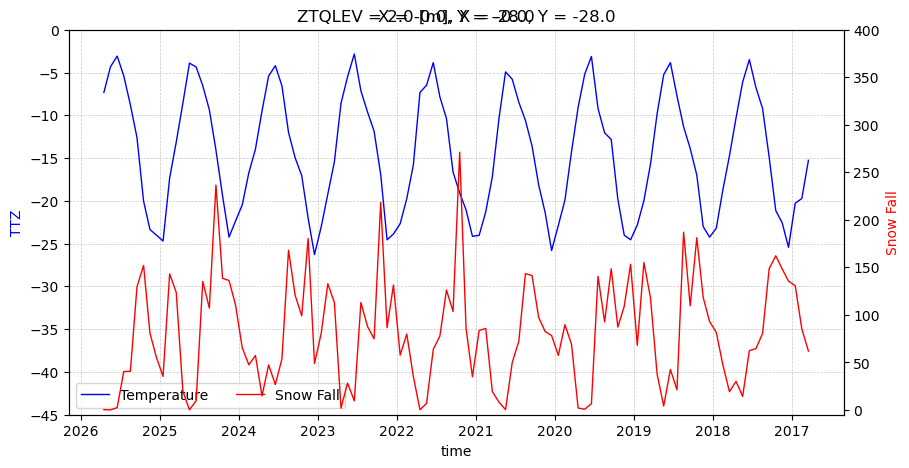

In [14]:
# Montly TTZ at Jasgulem ice core site

fig, ax1 = plt.subplots(figsize=(10,5))

# Température (axe gauche)
ds_TTZ_jasg = ds_TTZ.isel(Y=iY, X=iX).sel(time=slice("2016-09-30", "2025-10-01"))
ds_TTZ_jasg.plot(ax=ax1, label="Temperature", linewidth=1, color="blue")
ax1.set_ylabel("TTZ", color="blue")
ax1.set_ylim(-45, 0)
ax1.invert_xaxis()
ax1.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)


# Deuxième axe (droite) pour Snow Fall
ax2 = ax1.twinx()

ds_SF_jasg = ds_SF.isel(Y=iY, X=iX).sel(time=slice("2016-09-30", "2025-10-01"))
ds_SF_jasg.plot(ax=ax2, label="Snow Fall", linewidth=1, color="red")
ax2.set_ylabel("Snow Fall", color="red")
ax2.set_ylim(-5, 400)

# Légende combinée
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, ncol=2)

plt.show()

In [50]:
#Daily TTZ

years = range(2015, 2025)

files = [
    f"{sourceData_2}TTZ_daymean_MARv3.14_ER5_spin2_GRp_{year}.nc"
    for year in years
]

ds_TTZd = xr.open_mfdataset(
    files,
    combine="by_coords"
).isel(ZTQLEV=0).TTZ.load()

ds_TTZd = ds_TTZd.assign_coords(X=np.round(ds_TTZd.X.values))
ds_TTZd = ds_TTZd.assign_coords(Y=np.round(ds_TTZd.Y.values))
ds_TTZd = ds_TTZd.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZd = ds_TTZd[:,k:-k,k:-k]

In [16]:
#Daily SF
years = range(2015, 2025)

files = [
    f"{sourceData_2}SF_daysum_MARv3.14_ER5_spin2_GRp_{year}.nc"
    for year in years
]

ds_SFd = xr.open_mfdataset(
    files,
    combine="by_coords"
).SF.load()

ds_SFd = ds_SFd.assign_coords(X=np.round(ds_SFd.X.values))
ds_SFd = ds_SFd.assign_coords(Y=np.round(ds_SFd.Y.values))
ds_SFd = ds_SFd.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SFd = ds_SFd[:,k:-k,k:-k]

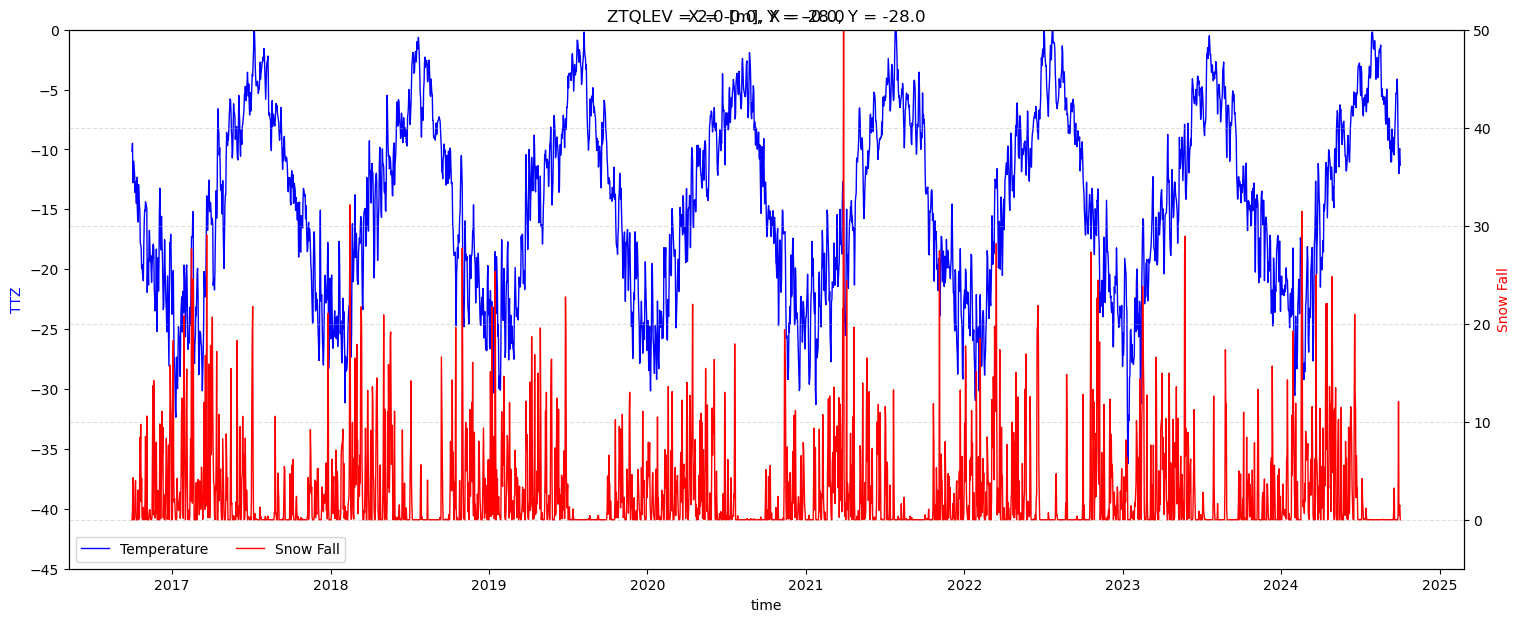

In [17]:
# Daily TTZ at Jasgulem ice core site

fig, ax1 = plt.subplots(figsize=(18,7))

# Température (axe gauche)
ds_TTZd_jasg = ds_TTZd.isel(Y=iY, X=iX).sel(time=slice("2016-09-30", "2024-10-01"))
ds_TTZd_jasg.plot(ax=ax1, label="Temperature", linewidth=1, color="blue")
ax1.set_ylabel("TTZ", color="blue")
ax1.set_ylim(-45, 0)

# Deuxième axe (droite) pour Snow Fall
ax2 = ax1.twinx()

ds_SFd_jasg = ds_SFd.isel(Y=iY, X=iX).sel(time=slice("2016-09-30", "2024-10-01"))
ds_SFd_jasg.plot(ax=ax2, label="Snow Fall", linewidth=1, color="red")
ax2.set_ylabel("Snow Fall (mmWE/day)", color="red")
ax2.set_ylim(-5, 50)

# Légende combinée
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, ncol=2)

# plt.title("Jasgulem ice core location")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

#### AWS CR800 dataset

/tmp/ipykernel_936106/2402202465.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=3)


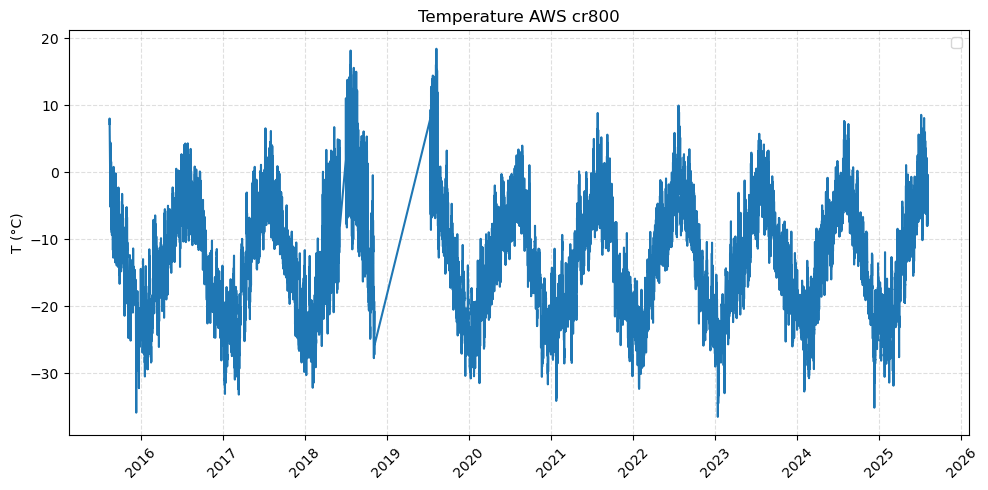

In [38]:
# Hourly CR800 Temperature

plt.figure(figsize=(10,5))

#plt.plot(time_cr800, T_cr800)

mask = (T_cr800_hr > -50) & (T_cr800_hr < 40)
plt.plot(time_cr800_hr[mask], T_cr800_hr[mask])

plt.legend(ncol=3)
plt.title("Temperature AWS cr800")
plt.ylabel("T (°C)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [46]:
### extract daily mean of Temperature for AWS CR800 dataset

time = pd.to_datetime(time_cr800_hr)

df = pd.DataFrame({
    "time": time,
    "T": T_cr800_hr
})

df = df.set_index("time")

# moyenne journalière
T_cr800_dy = df.resample("D").mean()

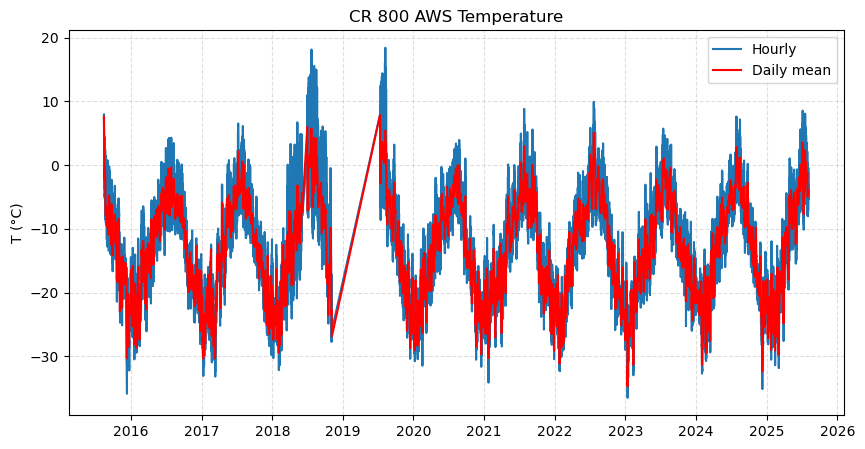

In [48]:
plt.figure(figsize=(10,5))

# --- horaire ---
mask_hr = (T_cr800_hr > -50) & (T_cr800_hr < 40)
plt.plot(time_cr800_hr[mask_hr], T_cr800_hr[mask_hr], label="Hourly")

# --- journalier ---
mask_dy = (T_cr800_dy["T"] > -50) & (T_cr800_dy["T"] < 40)
plt.plot(
    T_cr800_dy.index[mask_dy],
    T_cr800_dy["T"][mask_dy],
    label="Daily mean",
    color='red'
)

plt.legend()
plt.title("CR 800 AWS Temperature")
plt.ylabel("T (°C)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

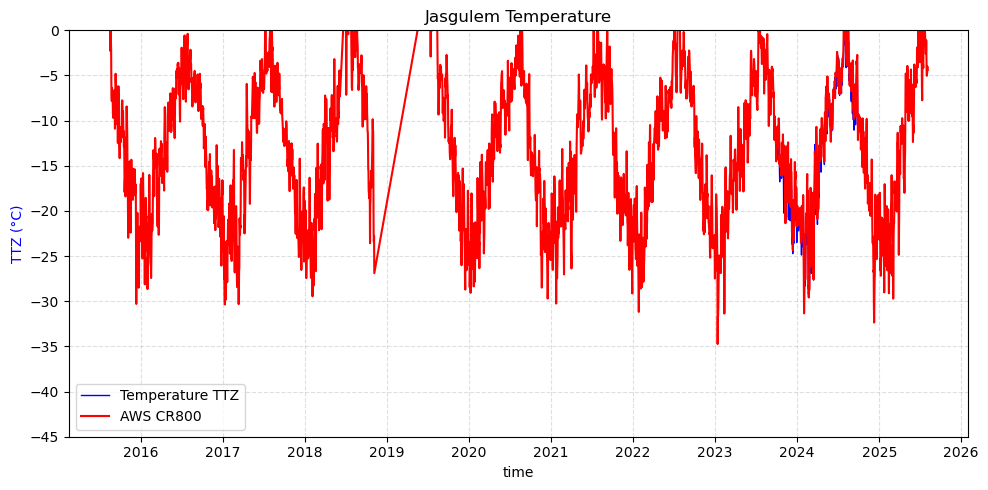

In [131]:
fig, ax1 = plt.subplots(figsize=(10,5))

# --- TTZ (xarray) ---
ds_TTZd_jasg = ds_TTZd.isel(Y=iY, X=iX).sel(
    time=slice("2023-09-30", "2024-10-01")
)

ds_TTZd_jasg.plot(
    ax=ax1,
    label="Temperature TTZ",
    linewidth=1,
    color="blue"
)

ax1.set_ylabel("TTZ (°C)", color="blue")
ax1.set_ylim(-45, 0)

# --- CR800 ---
mask_dy = (T_cr800_dy["T"] > -50) & (T_cr800_dy["T"] < 40)

ax1.plot(
    T_cr800_dy.index[mask_dy],
    T_cr800_dy["T"][mask_dy],
    label="AWS CR800",
    color="red"
)

# --- mise en forme ---
ax1.set_title("Jasgulem Temperature")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend()


plt.tight_layout()
plt.show()

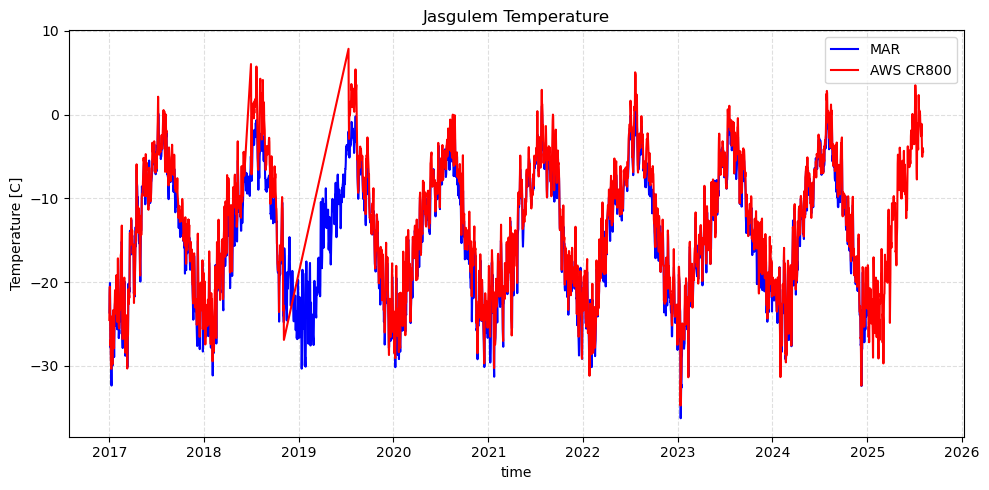

In [135]:
time_start ="2017-01-01"
time_end = "2026-12-31"

fig, ax1 = plt.subplots(figsize=(10,5))

# --- TTZ ---
ds_TTZd_jasg = ds_TTZd.isel(Y=iY, X=iX).sel(
    time=slice(time_start, time_end)
)

ds_TTZd_jasg.plot(ax=ax1, color="blue", label='MAR')

# --- AWS ---
aws_2123 = T_cr800_dy.loc[time_start:time_end]

mask_dy = (aws_2123["T"] > -50) & (aws_2123["T"] < 40)

ax1.plot(aws_2123.index[mask_dy], aws_2123["T"][mask_dy], color="red", label='AWS CR800')

ax1.set_title("Jasgulem Temperature")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend()

plt.tight_layout()
plt.show()

#### MAR représente très bien la température a Jasgulem de CR800

### Evaluer T max et T min pendant les periodes de précip

In [129]:
time_start ="2017-01-01"
time_end = "2025-12-31"

precip_threshold = 1 #mmWE/day

ds_TTZd_jasg = ds_TTZd.isel(Y=iY, X=iX).sel(time=slice(time_start, time_end))
ds_TTZd_jasg_filtered = ds_TTZd.isel(Y=iY, X=iX).where(ds_SFd_jasg > precip_threshold).sel(time=slice(time_start, time_end))
ds_TTZd_jasg_filtered_monthly = ds_TTZd_jasg_filtered.resample(time="1MS").mean()

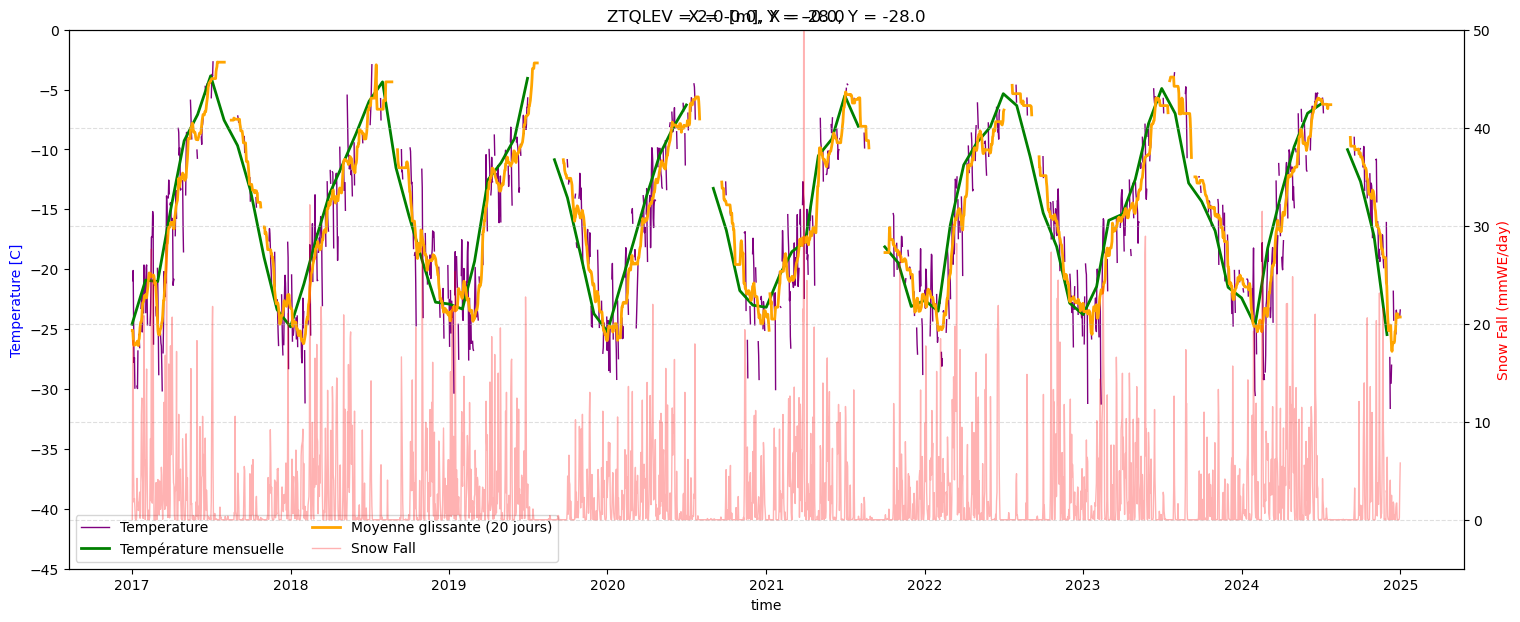

In [144]:
time_start ="2017-01-01"
time_end = "2025-12-31"

precip_threshold = 1 #mmWE/day

fig, ax1 = plt.subplots(figsize=(18,7))

# Température (axe gauche)
##ds_TTZd_jasg = ds_TTZd.isel(Y=iY, X=iX).sel(time=slice(time_start, time_end))
#ds_TTZd_jasg.plot(ax=ax1, label="Temperature", linewidth=1, color="blue")

#ds_TTZd_jasg_filtered = ds_TTZd.isel(Y=iY, X=iX).where(ds_SFd_jasg > precip_threshold).sel(time=slice(time_start, time_end))
ds_TTZd_jasg_filtered.plot(ax=ax1, label="Temperature", linewidth=1, color="purple")
ax1.set_ylabel("TTZ", color="blue")
ax1.set_ylim(-45, 0)

# Calcul de la moyenne mensuelle
#ds_TTZd_jasg_filtered_monthly = ds_TTZd_jasg_filtered.groupby("time.month").mean()
ds_TTZd_jasg_filtered_monthly.plot(label="Température mensuelle", color="green", linewidth=2)

# Moyenne glissante 
window_size = 20  # Taille de la fenêtre pour la moyenne glissante
ds_TTZd_jasg_rolling = ds_TTZd_jasg_filtered.rolling(time=window_size, center=True, min_periods=1).mean()
ds_TTZd_jasg_rolling.plot(ax=ax1, label=f"Moyenne glissante ({window_size} jours)", color="orange", linewidth=2)


# Deuxième axe (droite) pour Snow Fall
ax2 = ax1.twinx()

ds_SFd_jasg = ds_SFd.isel(Y=iY, X=iX).sel(time=slice(time_start, time_end))
ds_SFd_jasg.plot(ax=ax2, label="Snow Fall", linewidth=1, color="red", alpha=0.3)
ax2.set_ylabel("Snow Fall (mmWE/day)", color="red")
ax2.set_ylim(-5, 50)

# Légende combinée
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, ncol=2)

# plt.title("Jasgulem ice core location")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()